In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


In [6]:
df = pd.read_csv("makrodata.csv", index_col=0)
df

,country,year,gdp,un,inf,pop,exp
1,BE,2020,463750.9,5.8,0.4,11522440,367276.2
2,BE,2021,506047.2,6.3,3.2,11554767,453546.7
3,BE,2022,561309.1,5.6,10.3,11617623,529995.7
4,BE,2023,602376.3,5.5,2.3,11742796,498425.5
5,BE,2024,620271.8,5.7,4.3,11817096,491708.5
...,...,...,...,...,...,...,...
151,CH,2020,663105.6,4.8,-0.8,8606033,421524.5
152,CH,2021,710646.0,5.1,0.5,8670300,497040.9
153,CH,2022,815869.1,4.1,2.7,8738791,611615.4
154,CH,2023,858396.6,4.1,2.3,8815385,603613.7


In [7]:
df["gdp_per_capita"] = df["gdp"] / df["pop"] *1000000
print(df["gdp_per_capita"])

df_2023 = df[df["year"] == 2023]

1       40247.629842
2       43795.534778
3       48315.313726
4       51297.518921
5       52489.359484
           ...      
151     77051.249978
152     81963.253867
153     93361.781967
154     97374.828212
155    100024.870964
Name: gdp_per_capita, Length: 155, dtype: float64


In [8]:
eu_avg_gdp = df["gdp_per_capita"].mean()
eu_avg_unemp = df["un"].mean()


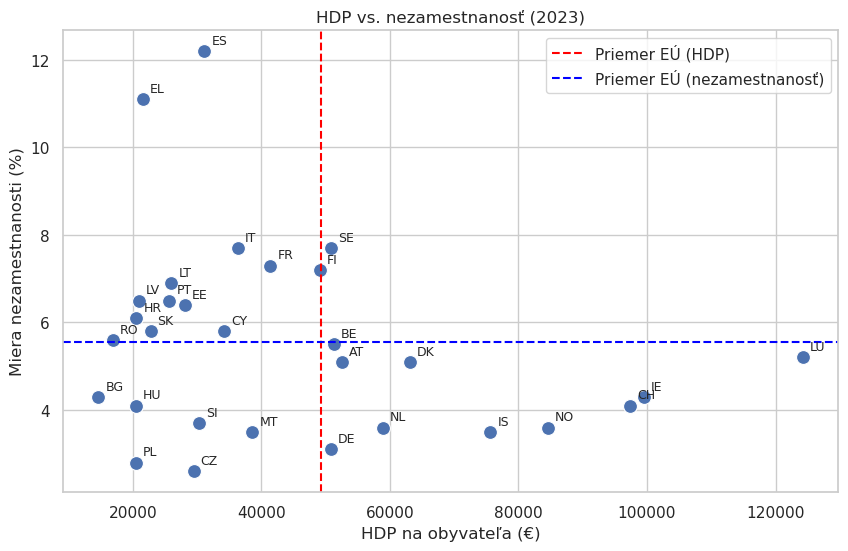

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# scatter pre rok 2023
sns.scatterplot(
    data=df_2023,
    x="gdp_per_capita",
    y="un", 
    s=100
)

# popisky krajín
for i, row in df_2023.iterrows():
    plt.annotate(
        row["country"],
        (row["gdp_per_capita"], row["un"]),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=9
    )

# priemery EÚ pre rok 2023 (vypočítané z df_2023)
eu_avg_gdp = df_2023["gdp_per_capita"].mean()
eu_avg_unemp = df_2023["un"].mean()

plt.axvline(eu_avg_gdp, color='red', linestyle='--', label="Priemer EÚ (HDP)")
plt.axhline(eu_avg_unemp, color='blue', linestyle='--', label="Priemer EÚ (nezamestnanosť)")

plt.xlabel("HDP na obyvateľa (€)")
plt.ylabel("Miera nezamestnanosti (%)")
plt.title("HDP vs. nezamestnanosť (2023)")
plt.legend()
plt.grid(True)
plt.show()


Na osi x máme HDP na obyvateľa (€)
Na osi y máme miera nezamestnanosti (%)
Každý bod = jedna krajina EÚ

Čo môžeme vidieť:

Body sa spravidla ťahajú zľava hore do prava dole → krajiny s vyšším HDP majú nižšiu nezamestnanosť.
Niektoré krajiny sú extrémne:
Veľmi vysoký HDP + nízka nezamestnanosť → typicky Luxembursko, Švédsko, Dánsko.
Nízky HDP + vysoká nezamestnanosť → napr. niektoré krajiny južnej alebo východnej EÚ.

Červená vertikálna čiara = priemer HDP EÚ
Modrá horizontálna čiara = priemer nezamestnanosti EÚ

Interpretácia:

Bod vpravo nad modrou čiarou → HDP nad priemerom, ale nezamestnanosť vyššia než priemer → paradoxné alebo špecifické ekonomické podmienky.
Bod vľavo pod modrou čiarou → nízky HDP, ale nízka nezamestnanosť → relatívne zdravá ekonomika napriek nižšiemu bohatstvu.
Popisky krajín

Pomáhajú identifikovať konkrétne krajiny, ktoré sú outliermi.
Napr. krajiny s extrémnym HDP alebo extrémnou nezamestnanosťou okamžite vyniknú.

Celkové zistenie
Existuje negatívna korelácia medzi HDP a nezamestnanosťou: vyšší HDP → zvyčajne nižšia nezamestnanosť.
Priemerné hodnoty EÚ fungujú ako referenčný benchmark, ktorý umožňuje vidieť, ktoré krajiny sú nad/pod priemerom v oboch parametroch.

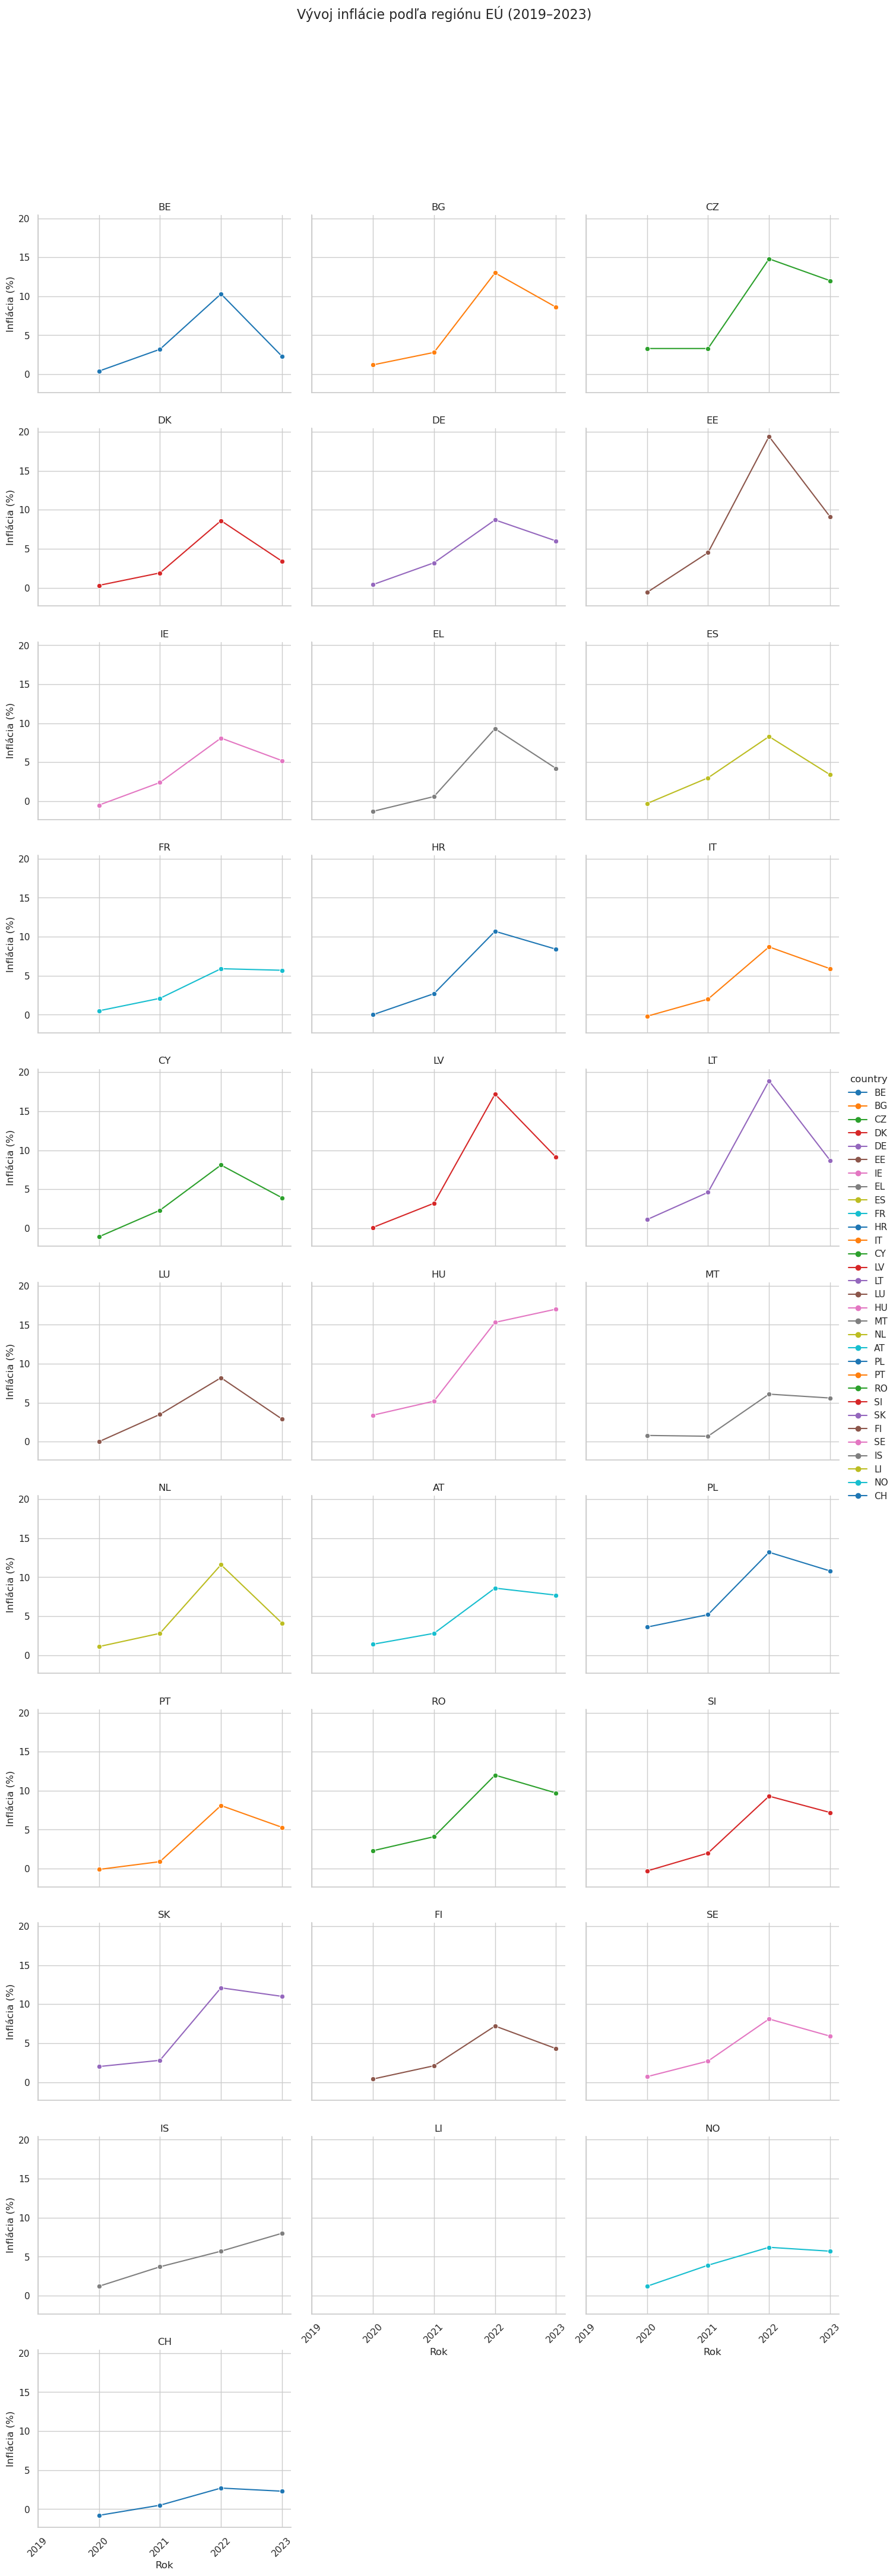

In [10]:
# filtrovanie rokov 2019–2023
df_plot = df[(df["year"] >= 2019) & (df["year"] <= 2023)]

sns.set(style="whitegrid")

g = sns.relplot(
    data=df_plot,
    x="year",
    y="inf",
    kind="line",
    hue="country",         
    col="country",         
    col_wrap=3,           
    marker="o",
    height=4,
    aspect=1.2,
    palette="tab10"
)

# nastavenie osí a názvov
g.set_axis_labels("Rok", "Inflácia (%)")
g.set_titles("{col_name}")

# presne roky na osi x
for ax in g.axes.flatten():
    ax.set_xticks([2019, 2020, 2021, 2022, 2023])
    ax.set_xticklabels([2019, 2020, 2021, 2022, 2023], rotation=45)

# celkový nadpis
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Vývoj inflácie podľa regiónu EÚ (2019–2023)", fontsize=16)

plt.show()



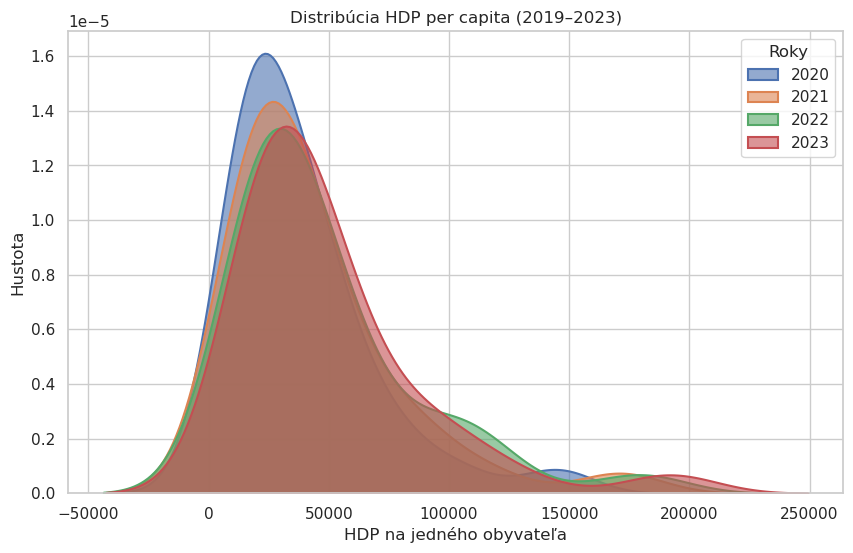

In [11]:
# filtrovanie rokov a HDP per capita
df_ridge = df[(df["year"] >= 2019) & (df["year"] <= 2023)]

sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

# Ridge plot – horizontálne hustoty
for i, year in enumerate(sorted(df_ridge["year"].unique())):
    subset = df_ridge[df_ridge["year"] == year]
    sns.kdeplot(
        subset["gdp_per_capita"], 
        fill=True, 
        alpha=0.6, 
        label=str(year),
        linewidth=1.5
    )

plt.xlabel("HDP na jedného obyvateľa")
plt.ylabel("Hustota")
plt.title("Distribúcia HDP per capita (2019–2023)")
plt.legend(title="Roky")
plt.show()

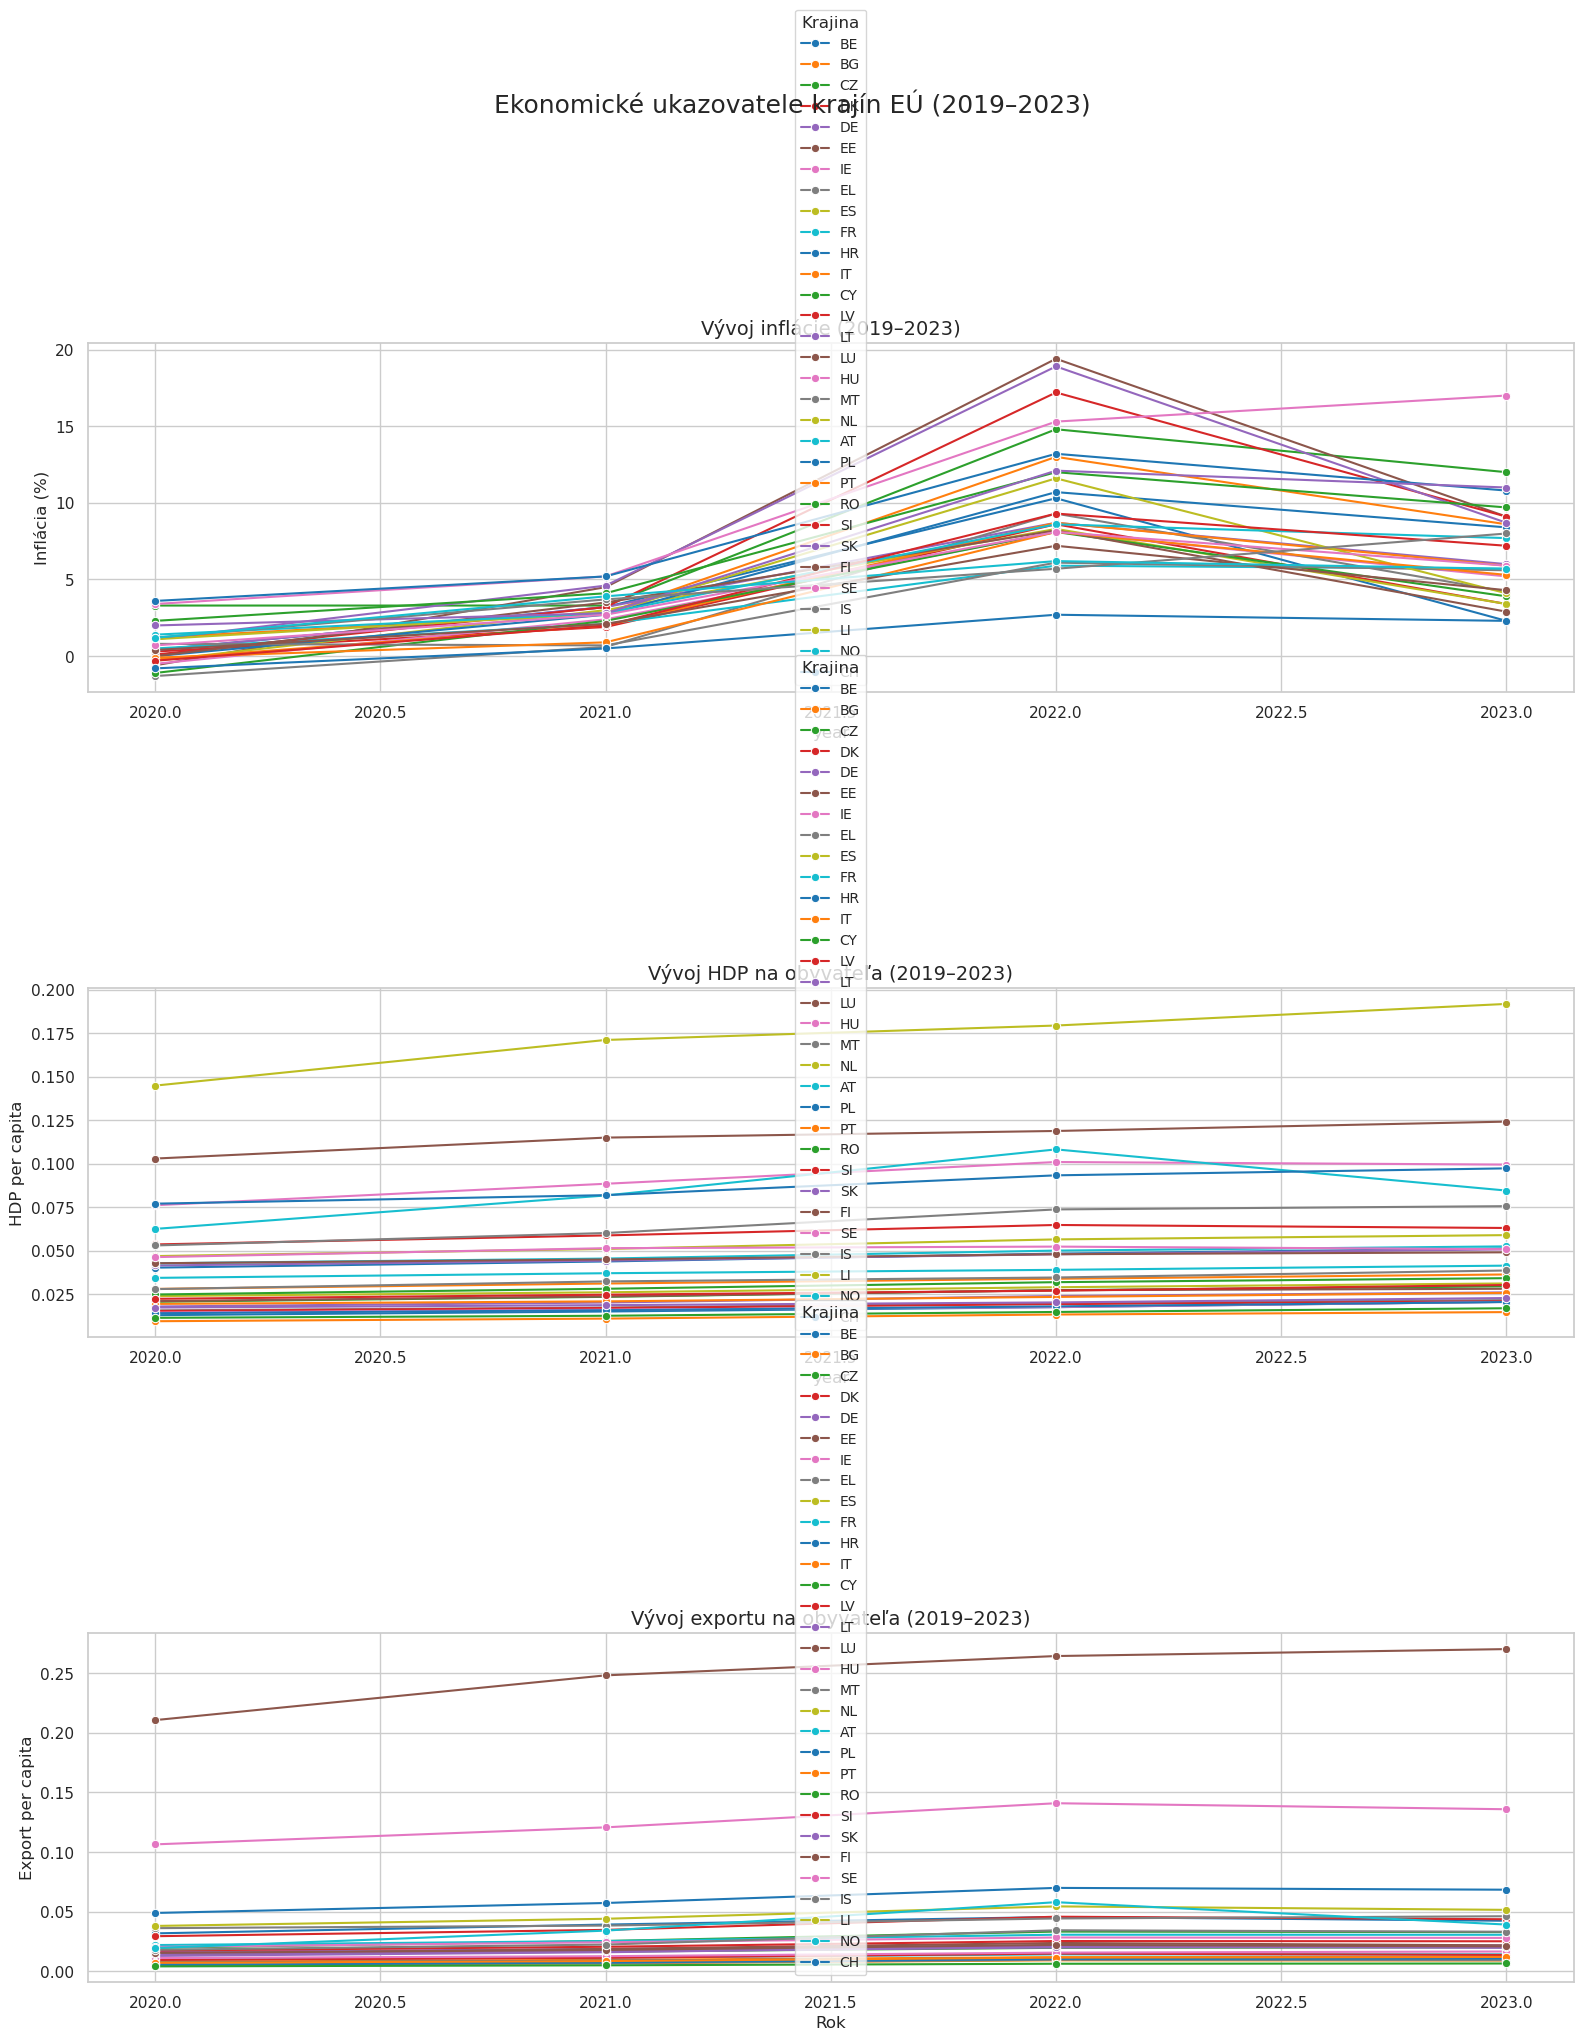

In [23]:
# filtrovanie rokov 2019–2023
df_plot = df[(df["year"] >= 2019) & (df["year"] <= 2023)]

sns.set(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(16, 20))  

# --- Graf 1: Inflácia ---
sns.lineplot(
    data=df_plot,
    x="year",
    y="inf",
    hue="country",
    marker="o",
    ax=axes[0],
    palette="tab10"
)
axes[0].set_title("Vývoj inflácie (2019–2023)", fontsize=14)
axes[0].set_ylabel("Inflácia (%)")
axes[0].legend(title="Krajina", fontsize=10, title_fontsize=12)

# --- Graf 2: HDP per capita ---
sns.lineplot(
    data=df_plot,
    x="year",
    y="gdp_per_capita",
    hue="country",
    marker="o",
    ax=axes[1],
    palette="tab10"
)
axes[1].set_title("Vývoj HDP na obyvateľa (2019–2023)", fontsize=14)
axes[1].set_ylabel("HDP per capita")
axes[1].legend(title="Krajina", fontsize=10, title_fontsize=12)

# --- Graf 3: Export per capita ---
sns.lineplot(
    data=df_plot,
    x="year",
    y="exp_per_capita",
    hue="country",
    marker="o",
    ax=axes[2],
    palette="tab10"
)
axes[2].set_title("Vývoj exportu na obyvateľa (2019–2023)", fontsize=14)
axes[2].set_ylabel("Export per capita")
axes[2].set_xlabel("Rok")
axes[2].legend(title="Krajina", fontsize=10, title_fontsize=12)

# jednotný nadpis
plt.suptitle("Ekonomické ukazovatele krajín EÚ (2019–2023)", fontsize=18)

plt.tight_layout()
plt.show()